# Исследовательский анализ данных и проверка гипотез сервиса Яндекс Афиша

Автор: Рубцов Д.А.

Дата: 23.05.2026

## Цели и задачи проекта 

Осенью 2024 года в сервисе Яндекс Афишы был отмечен тренд на увеличение количества заказов по сравнению с летом, в то время как средний чек наоборот снизился. В данном проекте попробуем разобраться в чем причины такой  динамики и дать соответствующие советы.
Для этого необходимо провести исследовательский анализ данных в Python, чтобы выявить инсайты об изменении пользовательских предпочтений и популярности событий, а также проверить гипотезы о разнице в поведении пользователей с мобильными и стационарными устройствами.

### Описание данных

Первый датасет `final_tickets_orders_df.csv` включает информацию обо всех заказах билетов, совершённых с двух типов устройств — мобильных и стационарных и содержит такие поля:


- order_id — уникальный идентификатор заказа.
- user_id — уникальный идентификатор пользователя.
- created_dt_msk — дата создания заказа (московское время).
- created_ts_msk — дата и время создания заказа (московское время).
- event_id — идентификатор мероприятия.
- cinema_circuit — сеть кинотеатров. Если не применимо, то здесь будет значение 'нет'.
- age_limit — возрастное ограничение мероприятия.
- currency_code — валюта оплаты, например rub для российских рублей.
- device_type_canonical — тип устройства, с которого был оформлен заказ, например mobile для мобильных устройств, desktop для стационарных.
- revenue — выручка от заказа.
- service_name — название билетного оператора.
- tickеts_count — количество купленных билетов.
- total — общая сумма заказа.
- days_since_prev — количество дней с предыдущей покупки для каждого пользователя.

Второй датасет `final_tickets_events_df` содержит информацию о событиях, включая город и регион события, а также информацию о площадке проведения мероприятия. Датасет содержит такие поля:


- event_id — уникальный идентификатор мероприятия.
- event_name — название мероприятия.
- event_type_description — описание типа мероприятия.
- event_type_main — основной тип мероприятия: театральная постановка, концерт и так далее.
- organizers — организаторы мероприятия.
- region_name — название региона.
- city_name — название города.
- venue_id — уникальный идентификатор площадки.
- venue_name — название площадки.
- venue_address — адрес площадки.

Дополнительный датасет `final_tickets_tenge_df.csv` содержит информацию о курсе тенге к российскому рублю за 2024 год. Значения в рублях представлены для 100 тенге. Датасет содержит такие поля:
- nominal — номинал (100 тенге).
- data — дата.
- curs — курс тенге к рублю.
- cdx — обозначение валюты (kzt).

## Загрузка данных и знакомство с ними

### Загрузка библиотек

Загрузим данные и получим первую информацию о них. Оценим объём данных, их корректность и соответствие описанию, а также выясним, какие шаги необходимо сделать на стадии предобработки данных.

In [1]:
# Загружаем необходимые библиотеки.
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns
from scipy import stats as st
from scipy.stats import ttest_ind
from scipy.stats import ttest_rel
from scipy.stats import mannwhitneyu

### Загрузка датасетов

In [2]:
# Загружаем данные датасетов.
df_orders = pd.read_csv('https://code.s3.yandex.net/datasets/final_tickets_orders_df.csv')
df_orders.info()
df_orders.head()

<class 'pandas.DataFrame'>
RangeIndex: 290849 entries, 0 to 290848
Data columns (total 14 columns):
 #   Column                 Non-Null Count   Dtype  
---  ------                 --------------   -----  
 0   order_id               290849 non-null  int64  
 1   user_id                290849 non-null  str    
 2   created_dt_msk         290849 non-null  str    
 3   created_ts_msk         290849 non-null  str    
 4   event_id               290849 non-null  int64  
 5   cinema_circuit         290849 non-null  str    
 6   age_limit              290849 non-null  int64  
 7   currency_code          290849 non-null  str    
 8   device_type_canonical  290849 non-null  str    
 9   revenue                290849 non-null  float64
 10  service_name           290849 non-null  str    
 11  tickets_count          290849 non-null  int64  
 12  total                  290849 non-null  float64
 13  days_since_prev        268909 non-null  float64
dtypes: float64(3), int64(4), str(7)
memory usage: 3

,order_id,user_id,created_dt_msk,created_ts_msk,event_id,cinema_circuit,age_limit,currency_code,device_type_canonical,revenue,service_name,tickets_count,total,days_since_prev
0,4359165,0002849b70a3ce2,2024-08-20,2024-08-20 16:08:03,169230,нет,16,rub,mobile,1521.94,Край билетов,4,10870.99,NaN
1,7965605,0005ca5e93f2cf4,2024-07-23,2024-07-23 18:36:24,237325,нет,0,rub,mobile,289.45,Мой билет,2,2067.51,NaN
2,7292370,0005ca5e93f2cf4,2024-10-06,2024-10-06 13:56:02,578454,нет,0,rub,mobile,1258.57,За билетом!,4,13984.16,75.0
3,1139875,000898990054619,2024-07-13,2024-07-13 19:40:48,387271,нет,0,rub,mobile,8.49,Лови билет!,2,212.28,NaN
4,972400,000898990054619,2024-10-04,2024-10-04 22:33:15,509453,нет,18,rub,mobile,1390.41,Билеты без проблем,3,10695.43,83.0


In [3]:
df_events = pd.read_csv('https://code.s3.yandex.net/datasets/final_tickets_events_df.csv')
df_events.info()
df_events.head()

<class 'pandas.DataFrame'>
RangeIndex: 22427 entries, 0 to 22426
Data columns (total 11 columns):
 #   Column                  Non-Null Count  Dtype
---  ------                  --------------  -----
 0   event_id                22427 non-null  int64
 1   event_name              22427 non-null  str  
 2   event_type_description  22427 non-null  str  
 3   event_type_main         22427 non-null  str  
 4   organizers              22427 non-null  str  
 5   region_name             22427 non-null  str  
 6   city_name               22427 non-null  str  
 7   city_id                 22427 non-null  int64
 8   venue_id                22427 non-null  int64
 9   venue_name              22427 non-null  str  
 10  venue_address           22427 non-null  str  
dtypes: int64(3), str(8)
memory usage: 1.9 MB


,event_id,event_name,event_type_description,event_type_main,organizers,region_name,city_name,city_id,venue_id,venue_name,venue_address
0,4436,e4f26fba-da77-4c61-928a-6c3e434d793f,спектакль,театр,№4893,Североярская область,Озёрск,2,1600,"Кладбище искусств ""Проблема"" и партнеры","наб. Загородная, д. 785"
1,5785,5cc08a60-fdea-4186-9bb2-bffc3603fb77,спектакль,театр,№1931,Светополянский округ,Глиноград,54,2196,"Лекции по искусству ""Свет"" Групп","ул. Ягодная, д. 942"
2,8817,8e379a89-3a10-4811-ba06-ec22ebebe989,спектакль,театр,№4896,Североярская область,Озёрск,2,4043,"Кинокомитет ""Золотая"" Инк","ш. Коммуны, д. 92 стр. 6"
3,8849,682e3129-6a32-4952-9d8a-ef7f60d4c247,спектакль,театр,№4960,Каменевский регион,Глиногорск,213,1987,"Выставка ремесел ""Свет"" Лтд","пер. Набережный, д. 35"
4,8850,d6e99176-c77f-4af0-9222-07c571f6c624,спектакль,театр,№4770,Лесодальний край,Родниковец,55,4230,"Фестивальный проект ""Листья"" Групп","пер. Проезжий, д. 9"


In [4]:
df_tenge = pd.read_csv('https://code.s3.yandex.net/datasets/final_tickets_tenge_df.csv')
df_tenge.info()
df_tenge.head()

<class 'pandas.DataFrame'>
RangeIndex: 357 entries, 0 to 356
Data columns (total 4 columns):
 #   Column   Non-Null Count  Dtype  
---  ------   --------------  -----  
 0   data     357 non-null    str    
 1   nominal  357 non-null    int64  
 2   curs     357 non-null    float64
 3   cdx      357 non-null    str    
dtypes: float64(1), int64(1), str(2)
memory usage: 11.3 KB


,data,nominal,curs,cdx
0,2024-01-10,100,19.9391,kzt
1,2024-01-11,100,19.7255,kzt
2,2024-01-12,100,19.5839,kzt
3,2024-01-13,100,19.4501,kzt
4,2024-01-14,100,19.4501,kzt


### Выводы

Информация по загруженным данным:
- Датафрейм `orders_df` содержит 14 столбцов и 290849 строк, пропуски содержатся пропуски в созданном столбце `days_since_prev`.
- Датафрейм `events_df` содержит 11 столбцов и 22427 строк без пропусков.
- Датафрейм `tenge_df` содержит 4 столбца и 357 строк без пропусков.

Во время предстоящей предобработки данных необходимо будет сделать следующие шаги:
    
- Объединить датафреймы в один. Для дальнейшего анализа и решения поставленных задач целесообразнее иметь всю информацию сразу.
- Необходимо создать новый столбец с приведенной к единой валюте выручкой.
- Убедиться, что пропуски в столбце `days_since_prev` есть только у первых заказов.
- Проверить категориальные столбцы на неявные дубликаты и ошибки, а числовые - на наличие аномалий и выбросов.
- Уменьшить размерность числовых столбцов при необходимости.
- При загрузке датафреймов некоторые столбцы поменяли формат на `object` и для дальнейшего анализа формат нужно изменить на подходящий.
- Во время предобработки необходимо проверить данные на полные и неполные дубликаты.

## Предобработка данных и подготовка их к исследованию

Перед исследовательским анализом необходимо провести тщательную предобработку, чтобы избежать ошибок и искажений в дальнейших действиях. Необходимо выполнить следующее:
- Объединить датафреймы в один для полноты информации.
- Проверить данные на пропуски.
- Изучить значения в ключевых столбцах.
- Проверить явные и неявные дубликаты.
- Создать несколько новых столбцов, которые пригодятся в дальнейшем анализе.
- Провести преобразования типов данных.

### Объединение данных

Перед объединением убедимся, что ключи, по которым мы будем объединять таблицы, не задублированы.

In [5]:
# Проверим датафрейм df_events на дубликаты по ключу
print('Найдено дубликатов по ключу event_id:',df_events.duplicated(subset=['event_id']).sum())

Найдено дубликатов по ключу event_id: 0


In [6]:
# Теперь объединяем датафреймы в один
df = df_orders.merge(df_events, on='event_id', how='left')
df.info()
# Записываем кол-во строк датафрейма
rows = df.shape[0]

<class 'pandas.DataFrame'>
RangeIndex: 290849 entries, 0 to 290848
Data columns (total 24 columns):
 #   Column                  Non-Null Count   Dtype  
---  ------                  --------------   -----  
 0   order_id                290849 non-null  int64  
 1   user_id                 290849 non-null  str    
 2   created_dt_msk          290849 non-null  str    
 3   created_ts_msk          290849 non-null  str    
 4   event_id                290849 non-null  int64  
 5   cinema_circuit          290849 non-null  str    
 6   age_limit               290849 non-null  int64  
 7   currency_code           290849 non-null  str    
 8   device_type_canonical   290849 non-null  str    
 9   revenue                 290849 non-null  float64
 10  service_name            290849 non-null  str    
 11  tickets_count           290849 non-null  int64  
 12  total                   290849 non-null  float64
 13  days_since_prev         268909 non-null  float64
 14  event_name              290611 

В объединенном датафрейме 24 столбца и 290849 строк.

### Проверка на пропуски

Теперь необходимо провести дальнейшую проверку и понять, что делать с пропусками, аномальными значениями, дубликатами, если такие имеются.

In [7]:
# Проверим сколько пропусков содержится в объединенном датафрейме
df.isna().sum()[df.isna().sum() > 0]

days_since_prev           21940
event_name                  238
event_type_description      238
event_type_main             238
organizers                  238
region_name                 238
city_name                   238
city_id                     238
venue_id                    238
venue_name                  238
venue_address               238
dtype: int64

Обнаружено 21940 пропусков в столбце `days_since_prev` и 238 пропусков в данных присоединенного датафрейма `df_events`. Наличие пропусков датафрейма `df_events` может говорить о неполной информации для событий датафрейма `df_orders`. Ввиду их небольшого числа, их нужно удалить.

In [8]:
df[['created_dt_msk','created_ts_msk']] = (
    df[['created_dt_msk','created_ts_msk']].apply(pd.to_datetime)
)
# Сортируем датафрейм
df = df.sort_values(['user_id', 'created_ts_msk'])
# Далем пересчет дней с предыдущего заказа
df['days_since_prev'] = (
    df.groupby('user_id')['created_ts_msk']
      .diff()
      .dt.days
)

In [9]:
# Проверяем, что пропуски в days_since_prev только у первых заказов
(df['days_since_prev'].isna() == (df.groupby('user_id').cumcount() == 0)).all()

np.True_

In [10]:
# Выделяем колонки кроме days_since_prev
cols = df.columns.drop('days_since_prev')
# Удаляем пропуски
df = df.dropna(subset=cols)

In [11]:
# Убеждаемся в заполнении пропусков
df.isna().sum()[df.isna().sum()>0]

days_since_prev    21914
dtype: int64

21913 пропусков осталось только в столбце `days_since_prev`.

### Проверка категориальных значений

В данном датафрейме под категориальные номинальные значения попадают столбцы `cinema_circuit`, `currency_code`, `device_type_canonical`, `service_name`, `event_name`, `event_type_main`, `organizers`, `region_name`, `city_name` и `venue_name`.
Проверим их на предмет ошибок в данных.

In [12]:
categories = [
    'cinema_circuit',
    'currency_code',
    'device_type_canonical',
    'service_name',
    'event_name',
    'event_type_main',
    'organizers',
    'region_name',
    'city_name',
    'venue_name'
]

for col in categories:
    print(col)
    display(df[col].value_counts(ascending=True).head(7))
    print()

cinema_circuit


cinema_circuit
ЦентрФильм         1
Киномакс           7
Москино            7
КиноСити         122
Другое          1261
нет           289213
Name: count, dtype: int64


currency_code


currency_code
kzt      5069
rub    285542
Name: count, dtype: int64


device_type_canonical


...

region_name
Теплоозёрский округ          7
Сосноводолинская область    10
Верхозёрский край           11
Крутоводский регион         18
Лесноярский край            19
Яснопольский округ          21
Светолесский край           24
Name: count, dtype: int64


city_name


city_name
Яблоновец       1
Сосновогорск    1
Мироград        1
Чистояр         1
Синеполинск     1
Радужовинск     1
Айсуак          1
Name: count, dtype: int64


venue_name


venue_name
Клуб любителей книг "Обилие" Инк                 1
Народный ансамбль "Стройка" Лтд                  1
Клуб рок-музыки "Запись" Инкорпорэйтед           1
Лаборатория по созданию комиксов "Galaxy" Инк    1
Лаборатория полевых исследований "Вдох" Лтд      1
Клуб настольных игр "Воображение" Лтд            1
Центр по изучению культуры "Остров" Групп        1
Name: count, dtype: int64

Среди просмотренных значений вышеуказанных столбцов можно отметить единичные значения в столбце с сетью кинотеатров `ЦентрФильм`, `Киномакс` и `Москино`, а также небольшие значения в столбце с билетными операторами. Все они являются уникальными именами собственными и корректировке не подлежат. Грамматические ошибки в данных не обнаружены.

### Проверка количественных значений

Проверим, есть ли в столбце с выручкой отрицательные значения.

In [13]:
print('Всего строк с отрицательным значением выручки:',df[df['revenue']<0].shape[0])
print('Всего строк с нулевым значением выручки:',df[df['revenue']==0].shape[0])

Всего строк с отрицательным значением выручки: 381
Всего строк с нулевым значением выручки: 5526


Аналогично проверим столбец с общей суммой заказа.

In [14]:
print('Всего строк с отрицательным значением общей суммы заказа:',df[df['total']<0].shape[0])
print('Всего строк с нулевым значением общей суммы заказа:',df[df['total']==0].shape[0])

Всего строк с отрицательным значением общей суммы заказа: 383
Всего строк с нулевым значением общей суммы заказа: 5505


Вероятнее всего, к отрицательному `revenue` и `total` могут относиться возвраты билетов или отмена заказов, хотя нельзя исключать и технические ошибки платежей. Поскольку выручка или сумма заказа не могут быть отрицательными и таких значений немного, их следует удалить.

Нулевыми значениями могут быть бесплатные билеты, поэтому их следует оставить.


In [15]:
# Удаляем строки с отрицательной выручкой и суммой заказа
df = df[(df['revenue'] >= 0) & (df['total'] >= 0)]
print('Осталось строк с отрицательной выручкой:',df[(df['revenue'] < 0) 
                                                    | (df['total'] < 0)].shape[0])

Осталось строк с отрицательной выручкой: 0


Проверим есть ли выбросы в данных относительно выручки и количества купленных билетов в заказе в разрезе представленной валюты.

In [16]:
# Проверим описательную статистику в рублевой выручке
df[df['currency_code'] == 'rub']['revenue'].describe()

count    285159.000000
mean        548.753302
std         872.101757
min           0.000000
25%         114.890000
50%         347.950000
75%         794.835000
max       81174.540000
Name: revenue, dtype: float64

In [17]:
# Аналогично в тенге
df[df['currency_code'] == 'kzt']['revenue'].describe()

count     5069.000000
mean      4995.206767
std       4916.752776
min          0.000000
25%        518.100000
50%       3698.830000
75%       7397.660000
max      26425.860000
Name: revenue, dtype: float64

Разброс данных в тенге сильнее, чем в рублях. Среднее, стандартное отклонение и 75-ый процентиль в `kzt` заметно больше, чем в `rub`. Вероятно, больший разброс данных обусловлен меньшим количеством заказов, поэтому они сильнее подвержены выбросам. Переходим к визуализациям.

In [18]:
# Функция для построения боксплота и гистограммы
def plot_box_hist(df, currency, column, title, bins=150):
    sns.set_theme(style="darkgrid")

    filtered_df = df[df['currency_code'] == currency]

    f, (ax_box, ax_hist) = plt.subplots(2, sharex=True, 
        gridspec_kw={"height_ratios": (.15, .85)},
        figsize=(10, 6))

    sns.boxplot(x=filtered_df[column], orient="h", ax=ax_box)

    sns.histplot(data=filtered_df, x=column, bins=bins, ax=ax_hist)
    ax_box.set(xlabel='')
    ax_box.set_title(title)

    plt.tight_layout()
    plt.show()

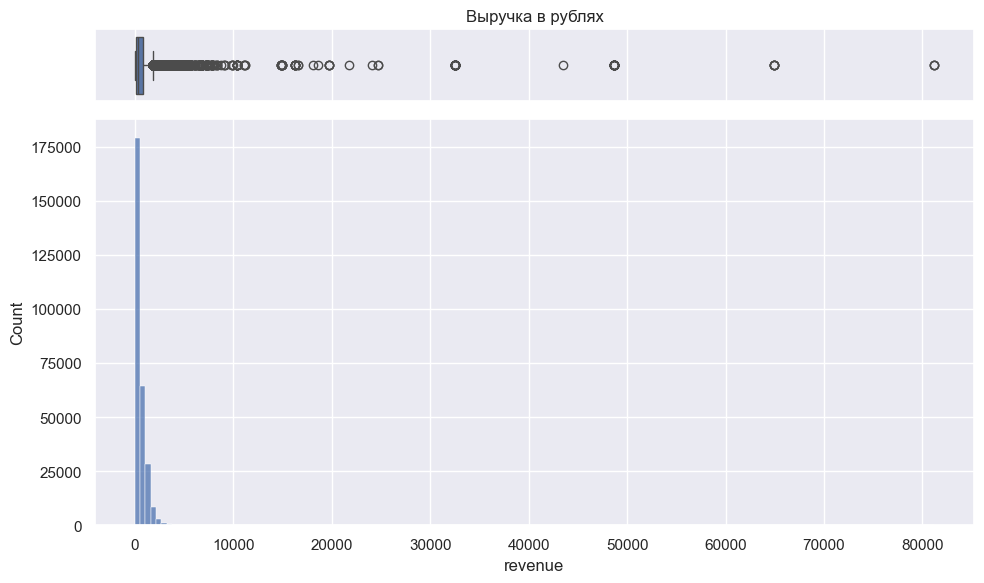

In [19]:
# Боксплот и гистограмма выручки в рублях
plot_box_hist(df=df, currency='rub', column='revenue', title='Выручка в рублях')

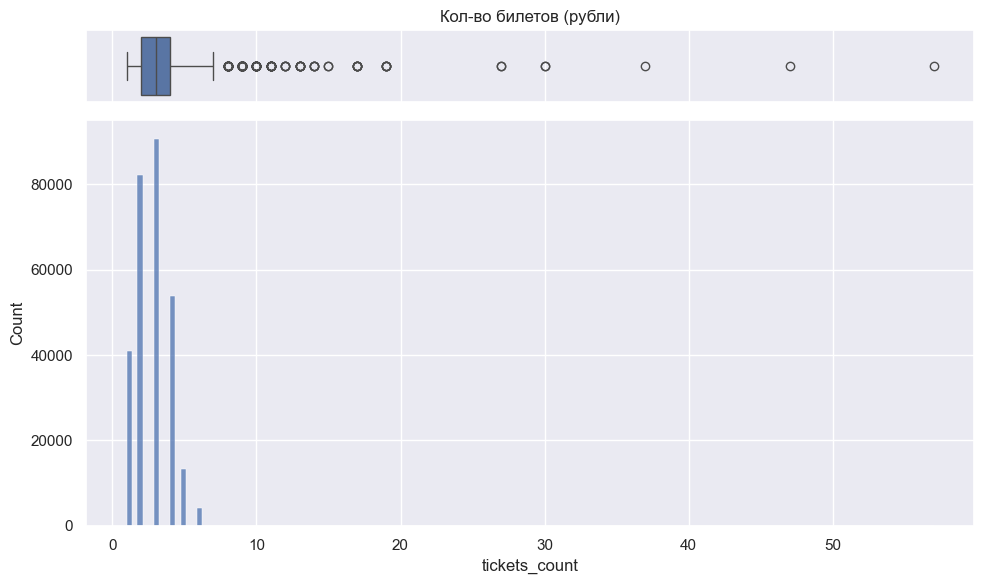

In [20]:
# Боксплот и гистограмма количества билетов в рублях
plot_box_hist(df=df, currency='rub', column='tickets_count', title='Кол-во билетов (рубли)')

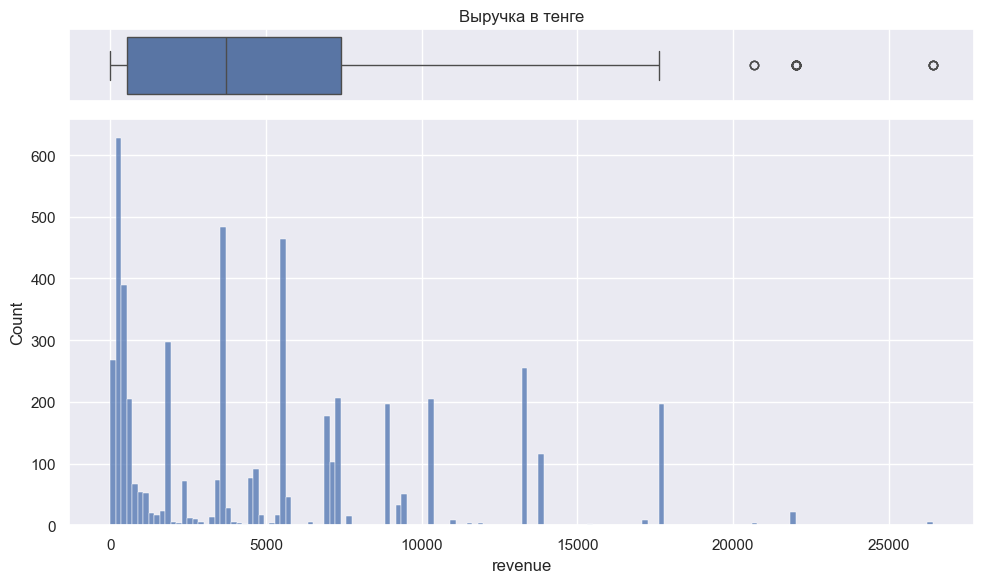

In [21]:
# Боксплот и гистограмма выручки в тенге
plot_box_hist(df=df,currency='kzt', column='revenue', title='Выручка в тенге')

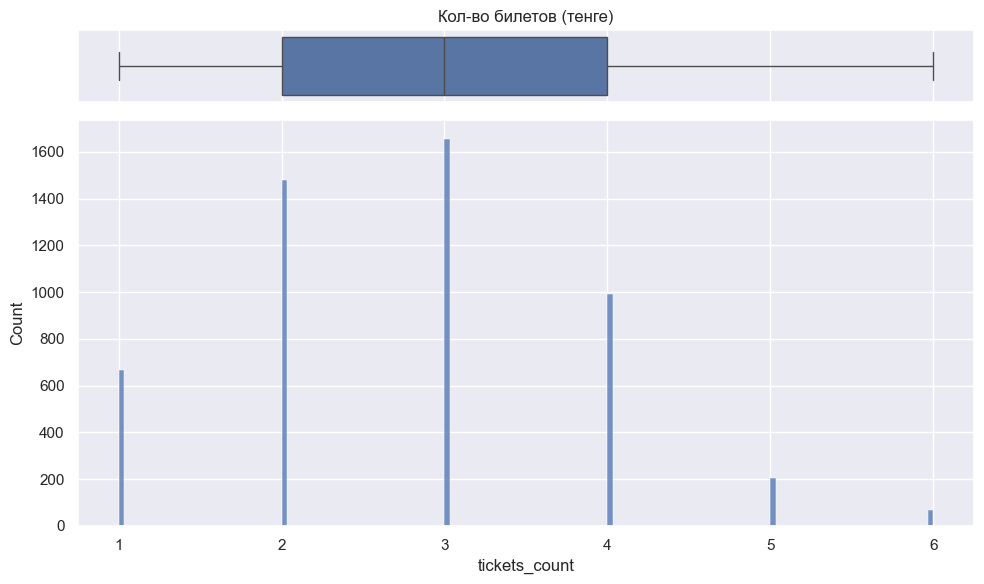

In [22]:
# Боксплот и гистограмма количества билетов в тенге
plot_box_hist(df=df, currency='kzt', column='tickets_count', title='Кол-во билетов (тенге)')

Выбросы присутствуют в обоих графиках с выручкой. Такие выбросы могли возникнуть, например, из-за перекупов, сделавших большой заказ для какого-либо мероприятия. Имеет смысл убрать хотя бы большую их часть, чтобы они не искажали основные данные. Отберем значения по 99 процентилю и посмотрим на результат.

In [23]:
before_quant = df.shape[0]
# Отбираем значения по 99 процентилю
df = df[(df['revenue']<=df['revenue'].quantile(0.99))&(df['tickets_count']<=df['tickets_count']
                                                       .quantile(0.99))]
after_quant = df.shape[0]
print('В результате отбора аномальных значений было убрано', before_quant - after_quant,'строк')

В результате отбора аномальных значений было убрано 3089 строк


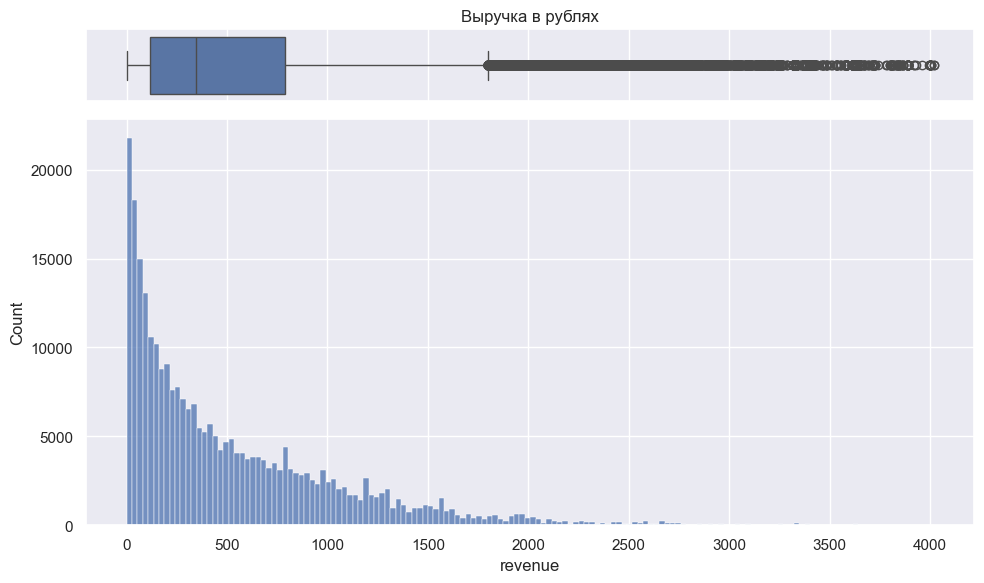

In [24]:
# Боксплот и гистограмма выручки в рублях
plot_box_hist(df=df, currency='rub', column='revenue', title='Выручка в рублях')

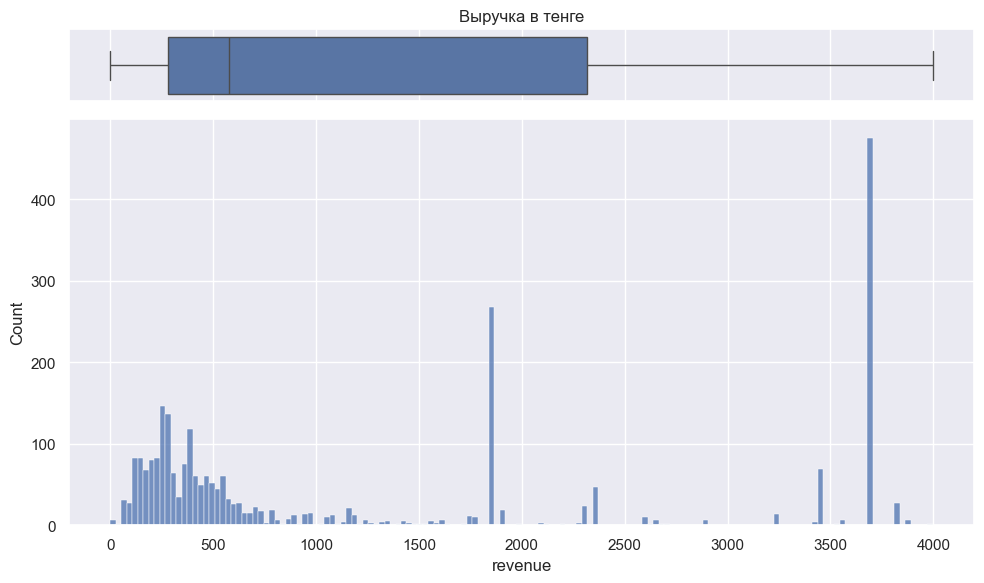

In [25]:
# Боксплот и гистограмма выручки в тенге
plot_box_hist(df=df,currency='kzt', column='revenue', title='Выручка в тенге')

Выбросы все еще присутствуют в рублевой выручке, но их стало значительно меньше и они находятся к третьему квантилю ближе, чем раньше. Следует их оставить поскольку дальнейшее "обрезание" данных рискует исказить их уже основательно.

### Проверка на дубликаты

Важным этапом предобработки данных является проверка на дубликаты, полные и неявные.

In [26]:
# Проверяем данные на наличие полных дубликатов
print('Всего полных дубликатов:',df.duplicated().sum())

Всего полных дубликатов: 0


In [27]:
# Проверим наличие дублированных строк по заказу
print('Всего неявных дубликатов по идентификтору заказа:',df.duplicated(subset=['order_id']).sum())

Всего неявных дубликатов по идентификтору заказа: 0


In [28]:
# Посмотрим есть ли одинаковые данные у разных заказов
print('Всего неявных дубликатов по данным кроме идентификатора заказа:',
      df.duplicated(subset=df.columns.drop(['order_id','days_since_prev'])).sum())

Всего неявных дубликатов по данным кроме идентификатора заказа: 40


Обнаружено 40 строк с одинаковыми данными у разных заказов.

In [29]:
# Рассмотрим строки-дубликаты
df[df.duplicated(subset=df.columns.drop(['order_id','days_since_prev']),keep=False)].head(6)

,order_id,user_id,created_dt_msk,created_ts_msk,event_id,cinema_circuit,age_limit,currency_code,device_type_canonical,revenue,...,event_name,event_type_description,event_type_main,organizers,region_name,city_name,city_id,venue_id,venue_name,venue_address
11777,1123983,06eb7897f65b433,2024-08-13,2024-08-13 16:31:07,183706,нет,18,rub,mobile,69.82,...,69796237-909b-42a7-bfb5-c1b8574c4c76,спектакль,театр,№1482,Светополянский округ,Глиноград,54.0,4443.0,"Центр культурного наследия ""Объединение"" и пар...","бул. Карбышева, д. 50"
11778,1123867,06eb7897f65b433,2024-08-13,2024-08-13 16:31:07,183706,нет,18,rub,mobile,69.82,...,69796237-909b-42a7-bfb5-c1b8574c4c76,спектакль,театр,№1482,Светополянский округ,Глиноград,54.0,4443.0,"Центр культурного наследия ""Объединение"" и пар...","бул. Карбышева, д. 50"
26894,1930705,0dc525d7bacbb0d,2024-07-31,2024-07-31 13:26:11,393430,нет,18,rub,desktop,1556.05,...,b33d7a0b-a715-47e3-803e-02482884a73e,концерт,концерты,№5048,Каменевский регион,Глиногорск,213.0,2704.0,"Летний фестиваль ""Симфония"" Лтд","бул. Боровой, д. 8/1 стр. 43"
26896,1930763,0dc525d7bacbb0d,2024-07-31,2024-07-31 13:26:11,393430,нет,18,rub,desktop,1556.05,...,b33d7a0b-a715-47e3-803e-02482884a73e,концерт,концерты,№5048,Каменевский регион,Глиногорск,213.0,2704.0,"Летний фестиваль ""Симфония"" Лтд","бул. Боровой, д. 8/1 стр. 43"
53715,1935113,206ea45ec11d478,2024-10-29,2024-10-29 16:46:54,442183,нет,16,rub,mobile,601.69,...,dcf6f06f-8499-41d7-8bc2-a0e3d7afe313,концерт,концерты,№894,Каменевский регион,Глиногорск,213.0,4363.0,"Студия дизайна ""Лестница"" Лимитед","наб. Школьная, д. 9/8 стр. 7/5"
53717,1935171,206ea45ec11d478,2024-10-29,2024-10-29 16:46:54,442183,нет,16,rub,mobile,601.69,...,dcf6f06f-8499-41d7-8bc2-a0e3d7afe313,концерт,концерты,№894,Каменевский регион,Глиногорск,213.0,4363.0,"Студия дизайна ""Лестница"" Лимитед","наб. Школьная, д. 9/8 стр. 7/5"


Дубликаты идут друг за другом. Вероятно, они были загружены ошибочно. Их следует удалить.

In [30]:
# Удаляем неявные дубликаты
df = df.drop_duplicates(subset=df.columns.drop(['order_id', 'days_since_prev']))

### Создание дополнительных столбцов

Для приведения всей выручки к рублю и создания соответствующего столбца, необходимо убедиться в корректности данных с курсом - по всем ли датам есть курс, адекватные ли там значения, какой номинал, представлены ли только тенге, и только потом присоединять датафрейм. Важно помнить, что при загрузке данных в датафрейме не было пропусков.

In [31]:
# Меняем формат столбцов со временем
df[['created_dt_msk','created_ts_msk']] = (
    df[['created_dt_msk','created_ts_msk']].apply(pd.to_datetime)
)
df_tenge['data'] = pd.to_datetime(df_tenge['data'])

In [32]:
# Проверим, есть ли в основном датафрейме даты, для которых отсутствует курс в df_tenge
missing_dates = (~df[df['currency_code']=='kzt']['created_dt_msk']
                 .isin(df_tenge['data'])).sum()
print('Всего строк в основном датафрейме, для которых нет курса в df_tenge по дате:',
      missing_dates)

Всего строк в основном датафрейме, для которых нет курса в df_tenge по дате: 0


In [33]:
# Посмотрим на значения столбца с курсом
df_tenge['curs'].describe()

count    357.000000
mean      19.755818
std        0.833798
min       17.848600
25%       19.120200
50%       19.876000
75%       20.443300
max       21.937100
Name: curs, dtype: float64

По информации о курсе видно, что никаких аномалий или пропусков нет. Стандартное отклонение минимально, разница между минимальным и максимальным значениями в пределах нормы.

In [34]:
# Убедимся, что в датафрейме один номинал и одна валюта
cols = ['nominal','cdx']
for col in cols:
    print(df_tenge[col].unique())

[100]
<StringArray>
['kzt']
Length: 1, dtype: str


In [35]:
print('Всего дубликатов по дате:',df_tenge.duplicated(subset=['data']).sum())

Всего дубликатов по дате: 0


В основном датафрейме нет дат, для которых нет курса по тенге, аномальных значений в `df_tenge` нет, номинал представлен одним числом, а валюта - одним курсом `kzt`. Теперь можно присоединять датафрейм.

In [36]:
# Присоединяем датафрейм с курсом к основному датафрейму
df = df.merge(df_tenge[['data','curs']],left_on='created_dt_msk',right_on='data',how='left')
# Создаем новый столбец с выручкой с заказа в единой валюте
df['revenue_rub'] = (
    df['revenue'].where(df['currency_code'] == 'rub', df['revenue'] * df['curs'] / 100)
)
# Убираем ненужные столбцы
df.drop(columns=['data','curs'],inplace=True)

In [37]:
# Создаем столбец с выручкой с продажи одного билета на мероприятие
df['one_ticket_revenue_rub'] = df['revenue_rub']/df['tickets_count']
# Создаем столбец с месяцем оформления заказа
df['month'] = df['created_dt_msk'].dt.month
# Создаем столбец с информацией о сезонности
df['season'] = (
    pd.cut(df['month'],bins=[1,2,5,8,11,12],labels=['зима','весна','лето','осень','зима'],
           right=True,ordered=False)
)

### Преобразования типов данных

После проведения основных этапов предобработки и создания новых столбцов заключительным шагом к подготовке данных будет изменение форматов и понижение размерности.

In [38]:
# Меняем формат и понижаем размерность там где необходимо
df[['created_dt_msk','created_ts_msk']] = (
    df[['created_dt_msk','created_ts_msk']].apply(pd.to_datetime)
)

df[['cinema_circuit','age_limit','device_type_canonical','currency_code','event_type_main']] = (
    df[['cinema_circuit','age_limit','device_type_canonical','currency_code','event_type_main']]
    .astype('category')
)

df[['order_id','event_id','tickets_count','city_id','venue_id']] = (
    df[['order_id','event_id','tickets_count','city_id','venue_id']]
    .apply(pd.to_numeric, downcast='integer')
)

df[['revenue','total','days_since_prev']] = (
    df[['revenue','total','days_since_prev']]
    .apply(pd.to_numeric, downcast='float')
)

После всех этапов подготовки данных сделаем пересчет столбца `days_since_prev`.

In [39]:
# Сортируем датафрейм
df = df.sort_values(['user_id', 'created_ts_msk'])
# Далем пересчет дней с предыдущего заказа
df['days_since_prev'] = (
    df.groupby('user_id')['created_ts_msk']
      .diff()
      .dt.days
)
# Обновляем индекс
df = df.reset_index(drop=True)

Теперь необходимо убедиться в том, что значения *Nan* содержатся только у первых заказов пользователей.

In [40]:
# Проверяем, что пропуски в days_since_prev только у первых заказов
(df['days_since_prev'].isna() == (df.groupby('user_id').cumcount() == 0)).all()

np.True_

Значение `True` показывает, что `NaN` есть только у первых заказов пользователей.

### Выводы

In [41]:
# Вновь посмотрим на информацию о датафрейме
df.info()
print()
print('Осталось строк после предобработки:',df.shape[0])
new_rows = rows - df.shape[0]
print('Всего строк удалено:',new_rows)

<class 'pandas.DataFrame'>
RangeIndex: 287099 entries, 0 to 287098
Data columns (total 28 columns):
 #   Column                  Non-Null Count   Dtype         
---  ------                  --------------   -----         
 0   order_id                287099 non-null  int32         
 1   user_id                 287099 non-null  str           
 2   created_dt_msk          287099 non-null  datetime64[us]
 3   created_ts_msk          287099 non-null  datetime64[us]
 4   event_id                287099 non-null  int32         
 5   cinema_circuit          287099 non-null  category      
 6   age_limit               287099 non-null  category      
 7   currency_code           287099 non-null  category      
 8   device_type_canonical   287099 non-null  category      
 9   revenue                 287099 non-null  float32       
 10  service_name            287099 non-null  str           
 11  tickets_count           287099 non-null  int8          
 12  total                   287099 non-null  

В результате проведенной предобработки данных:
- В датафрейме 287099 строк и 29 столбцов - 24 основных и 4 добавленных. Пропуски остались только в столбце `days_since_prev` и только для первых заказов пользователей.
- Удалено 3750 строк, в числе которых:
    - 238 строк с пропусками из присоединенного датафрейма `df_events`.
    - 383 строки с отрицательным значением столбцов `revenue` и `total`.
    - 3089 строк с аномальными значениями `revenue` и `tickets_count`.
    - 40 неявных дубликатов с дублирующейся информацией о пользователях.
- Созданы новые столбцы для удобства дальнейшего анализа:
    - revenue_rub — выручка с заказа, приведенная к единой валюте — российскому рублю.
    - one_ticket_revenue_rub — выручка с продажи одного билета на мероприятие.
    - month — месяц оформления заказа.
    - season — столбец с информацией о времени года проведенного события.
- Формат некоторых столбцов был изменен, а размерность числовых столбцов снижена. В датафрейме 6 категориальных, 11 числовых столбца, 2 столбца с форматом времени и 9 столбцов формата `object`.

## Исследовательский анализ данных

Более ранний анализ показал, что в данных наблюдается сезонность — осенью количество заказов увеличивается. На стадии исследовательского анализа необходимо изучить изменение пользовательской активности или пользовательского интереса в связи с сезонностью, чтобы понять, действительно ли увеличение количества заказов сопровождается уменьшением среднего чека. 

Для этого нужно проанализировать динамику по типу мероприятия, типу устройства и возрастному рейтингу в абсолютном и относительном значениях, а также посчитать процентную разницу выручки с продажи билетов.

### Анализ распределения заказов по сегментам и их сезонные изменения

Для того, чтобы узнать как менялась динамика заказов с июня по октябрь, построим линейные графики и столбчатые диаграммы по таким столбцам: `event_type_main`, `device_type_canonical` и `age_limit`. Также посмотрим как менялась выручка за один билет.

In [42]:
# Для начала создадим копию датафрейма и отфильтруем в нем данные, убрав ненужные категории
df_season = df.copy()
df_season['season'] = df_season['season'].cat.remove_unused_categories()
print(df_season['season'].unique())

['лето', 'осень']
Categories (2, str): ['лето', 'осень']


#### Количество заказов для каждого месяца

In [43]:
# Для начала создадим копию датафрейма и отфильтруем в нем данные, убрав ненужные категории
df_season = df.copy()
df_season['season'] = df_season['season'].cat.remove_unused_categories()
print(df_season['season'].unique())
print(df_season['month'].unique())

['лето', 'осень']
Categories (2, str): ['лето', 'осень']
[ 8  7 10  9  6]


In [44]:
# Создаем функцию для линейных графиков
def plot_line(df, col, title):
    data = df_season.groupby(['month', col])['order_id'].count().unstack()

    ax = data.plot(kind='line')

    ax.set_title(title)
    ax.set_xlabel('Месяц')
    ax.set_ylabel('Кол-во заказов')
    ax.set_xticks(range(6, 11))
    ax.grid(True)
    ax.set_ylim(bottom=0)
    
    plt.show()

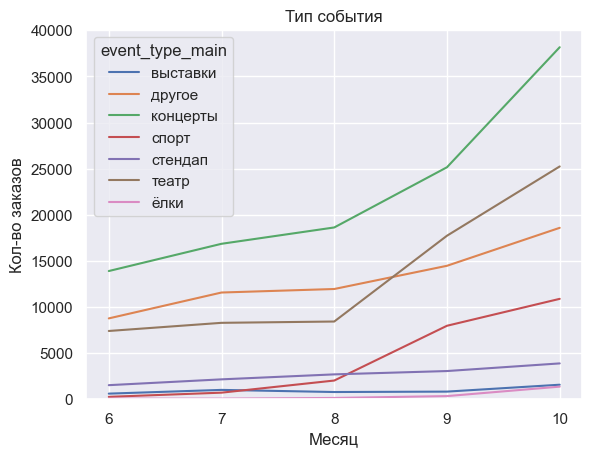

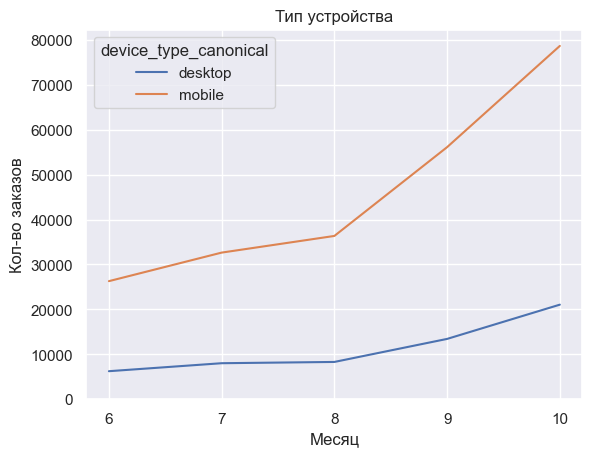

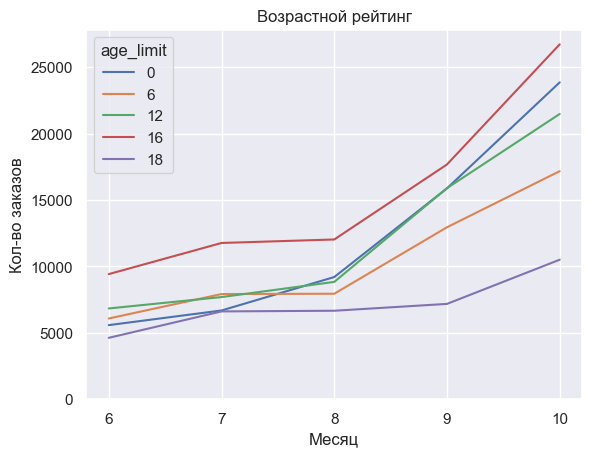

In [45]:
plot_line(df_season, 'event_type_main', 'Тип события')
plot_line(df_season, 'device_type_canonical', 'Тип устройства')
plot_line(df_season, 'age_limit', 'Возрастной рейтинг')

#### Сравнение распределения заказов билетов

In [46]:
# Создаем функцию для столбчатых диаграмм
def plot_bar(df, col, title, rotation):
    data = df_season.groupby([col,'season'])['order_id'].count().unstack()
    
    data = data.div(data.sum(axis=0), axis=1)
    ax = data.plot(kind='bar')

    ax.set_title(title)
    ax.set_xlabel('')
    ax.set_ylabel('Доля кол-ва заказов')
    ax.grid(True)
    ax.tick_params(axis='x', rotation=rotation)
    
    plt.show()

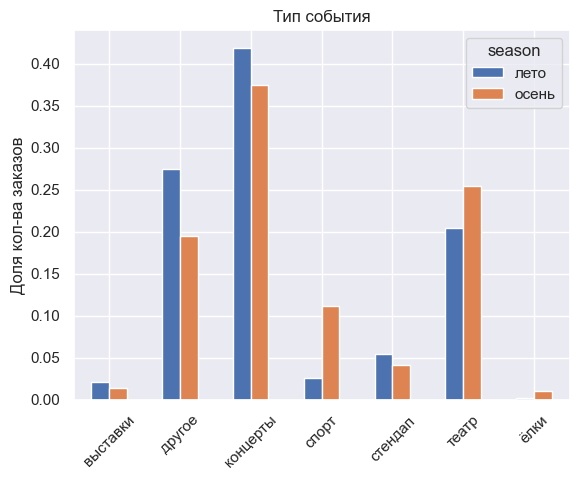

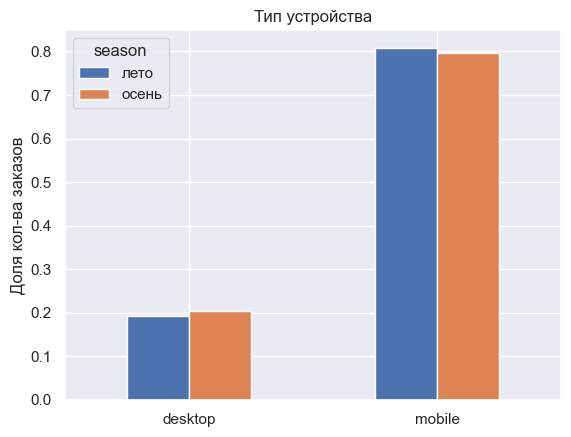

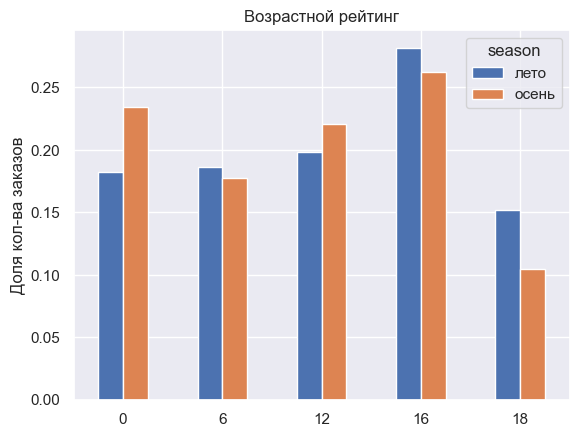

In [47]:
plot_bar(df_season, 'event_type_main', 'Тип события', 45)
plot_bar(df_season, 'device_type_canonical', 'Тип устройства', 0)
plot_bar(df_season, 'age_limit', 'Возрастной рейтинг', 0)

#### Изменение выручки с продажи одного билета

<Figure size 2000x600 with 0 Axes>

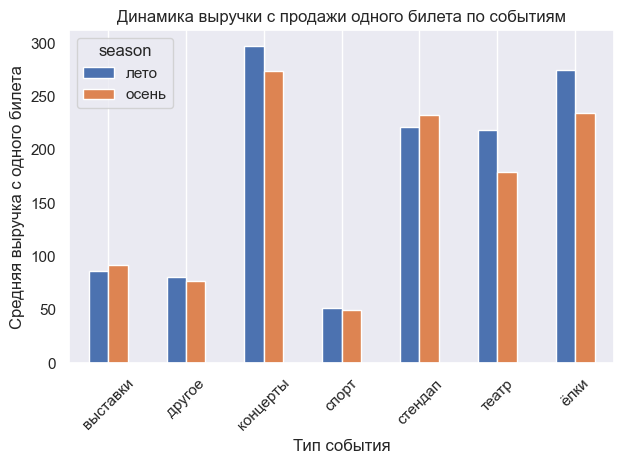

In [48]:
# Построим график изменения средней выручки с продажи одного билета
plt.figure(figsize=(20, 6))

one_ticket_bar = df_season.groupby(['event_type_main','season'])['one_ticket_revenue_rub'].mean().unstack()

one_ticket_bar.plot(kind='bar')
plt.title('Динамика выручки с продажи одного билета по событиям')
plt.xlabel('Тип события')
plt.ylabel('Средняя выручка с одного билета')
plt.grid(axis='y')
plt.tick_params(axis='x', rotation=45)

plt.tight_layout()
plt.show()

In [49]:
# Рассмотрим динамику выручки в процентах
relative_change = (
    (one_ticket_bar['осень'] - one_ticket_bar['лето'])
    / one_ticket_bar['лето'] * 100
).round(2)
print('Динамика выручки по типам событий в процентах\n',relative_change)
print('В среднем выручка уменьшилась на', relative_change.mean().round(2),'%')

Динамика выручки по типам событий в процентах
 event_type_main
выставки     6.49
другое      -4.59
концерты    -7.92
спорт       -3.76
стендап      5.13
театр      -17.84
ёлки       -14.76
dtype: float64
В среднем выручка уменьшилась на -5.32 %


#### Выводы

В результате анализа распределения заказов по сегментам можно отметить следующее:
- С наступлением осени количество заказов растет во всех рассмотренных сегмантах. Среди мероприятий можно отметить `концерты`, `театр`, `спорт` и `другое`, по типу устройства высокой положительной динамикой отличаются мобильные устройства, а по возрастному сегменту наблюдается значительный рост количества заказов по всех категориям до 18 лет.
- С распределением заказов по сегментам не все так однозначно. В то время как падает доля заказов в `концертах` и "`другом`", рост доли происходит в `театре` и `спорте`. По типам устройств доля заказов не претерпела значительных изменений, а по возрастному рейтингу доля заказов уменьшилась для возрастных рейтингов 16 и 18 лет.
- Что касается средней выручки с продажи одного билета, осенью наблюдается падение почти по всем типам мероприятий, в особенности у `театра`(-17.84%) и `ёлок`(-14.76%). Небольшую положительную динамику показали `выставки` (6.49%) и `стендап` (5.13%).
- Пользовательский интерес с наступлением осени увеличился, что может говорить в пользу фактора сезонности. Летние отпуска подошли к концу, начался новый учебный год. Люди чаще стали покупать билеты и ходить на различные мероприятия. Однако цена одного билета в среднем все же упала на **5,32%**. Возможные причины, а также значимость и случайность этой динамики еще предстоит выяснить.
- Важно добавить, что в данном исследовании мы полагаемся лишь на небольшой промежуток одного года, поэтому пока мы не можем с уверенностью говорить о влиянии сезонности. На динамику могли также повлиять и другие факторы, например, специфические маркетинговые кампании.

### Осенняя активность пользователей

Теперь исследуем активность пользователей осенью 2024 года, а именно проанализируем динамику изменений по дням по определеннвм параметрам и изучим недельную цикличность пользователей.

#### Анализ динамики изменений по дням

In [50]:
# Вычисляем цену одного билета
df['one_ticket_price'] = df['total'] / df['tickets_count']
# Создаем сводную таблицу с основными показателями осенней активности пользователей
pivot_autumn = pd.pivot_table(
    df[df['month'].isin([9, 10])],
    index=df['created_dt_msk'],
    values=['order_id', 'user_id', 'one_ticket_price'],
    aggfunc={
        'order_id': 'count',
        'user_id': 'nunique',
        'one_ticket_price': 'mean'
        #'one_ticket_revenue_rub': 'mean'
    }
).rename(columns={
        'order_id': 'orders_cnt',
        'user_id': 'dau'
})

pivot_autumn['orders_per_user'] = pivot_autumn['orders_cnt'] / pivot_autumn['dau']
pivot_autumn['orders_per_user'] = pivot_autumn['orders_per_user'].round(2)
pivot_autumn['one_ticket_price'] = pivot_autumn['one_ticket_price'].round(2)
pivot_autumn = pivot_autumn[['orders_cnt','dau','orders_per_user','one_ticket_price']]
pivot_autumn

,orders_cnt,dau,orders_per_user,one_ticket_price
created_dt_msk,,,,
2024-09-01,1346,569,2.37,2382.50
2024-09-02,1377,573,2.40,2396.16
2024-09-03,5094,777,6.56,1357.11
2024-09-04,1760,684,2.57,2501.51
2024-09-05,1936,739,2.62,2457.20
...,...,...,...,...
2024-10-27,2856,1034,2.76,2228.68
2024-10-28,2848,987,2.89,2032.72
2024-10-29,2877,1002,2.87,2148.50


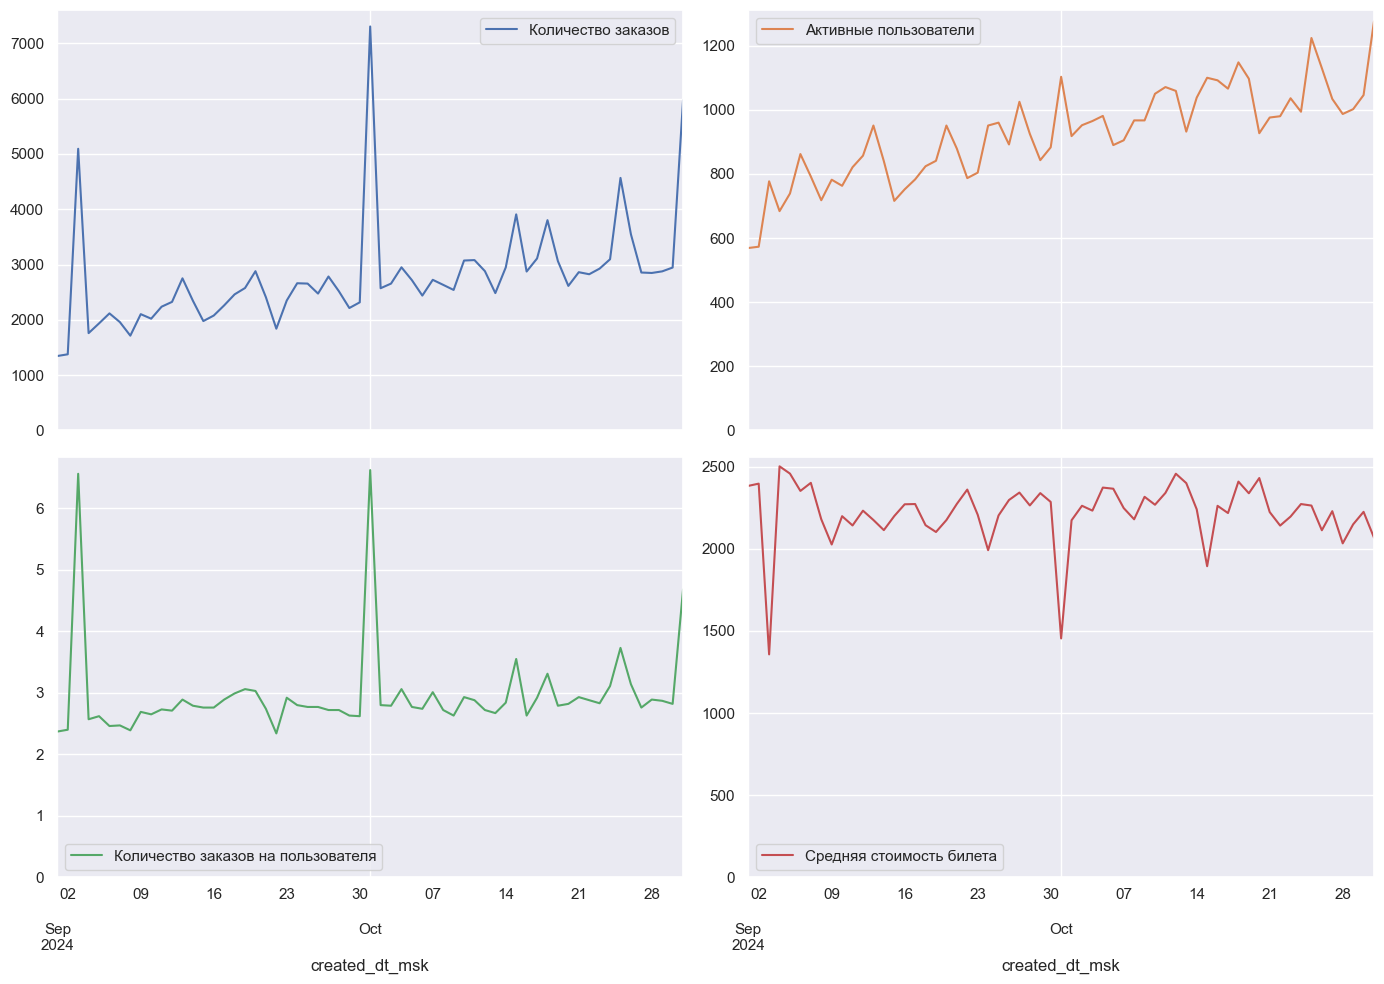

In [51]:
pivot_autumn.columns = [
    'Количество заказов',
    'Активные пользователи',
    'Количество заказов на пользователя',
    'Средняя стоимость билета'
]

pivot_autumn.plot(
    subplots=True,
    figsize=(14, 10),
    layout=(2,2),
    grid=True,
    legend=True,
    ylim=(0, None)
)

plt.tight_layout()
plt.show()

#### Изучение недельной цикличности пользовательской активности

In [52]:
# Посчитаем среднее количество активных пользователей за каждый день недели
week_dau = (
    df[df['month'].isin([9,10])]
    .groupby([
        df['created_dt_msk'].dt.day_name(),
        df['created_dt_msk'].dt.date
    ])['user_id'].nunique().groupby(level=0).mean()
)
# Считаем среднее по всей выборке
mean_line = (
    df[df['month'].isin([9,10])]
    .groupby(
        df['created_dt_msk'].dt.date
    )['user_id'].nunique().mean()
)

days = ['Monday', 'Tuesday', 'Wednesday', 'Thursday', 'Friday', 'Saturday', 'Sunday']

week_dau = week_dau.reindex(days)
week_dau

created_dt_msk
Monday        855.555556
Tuesday       936.222222
Wednesday     927.555556
Thursday      963.000000
Friday       1024.625000
Saturday      962.875000
Sunday        824.000000
Name: user_id, dtype: float64

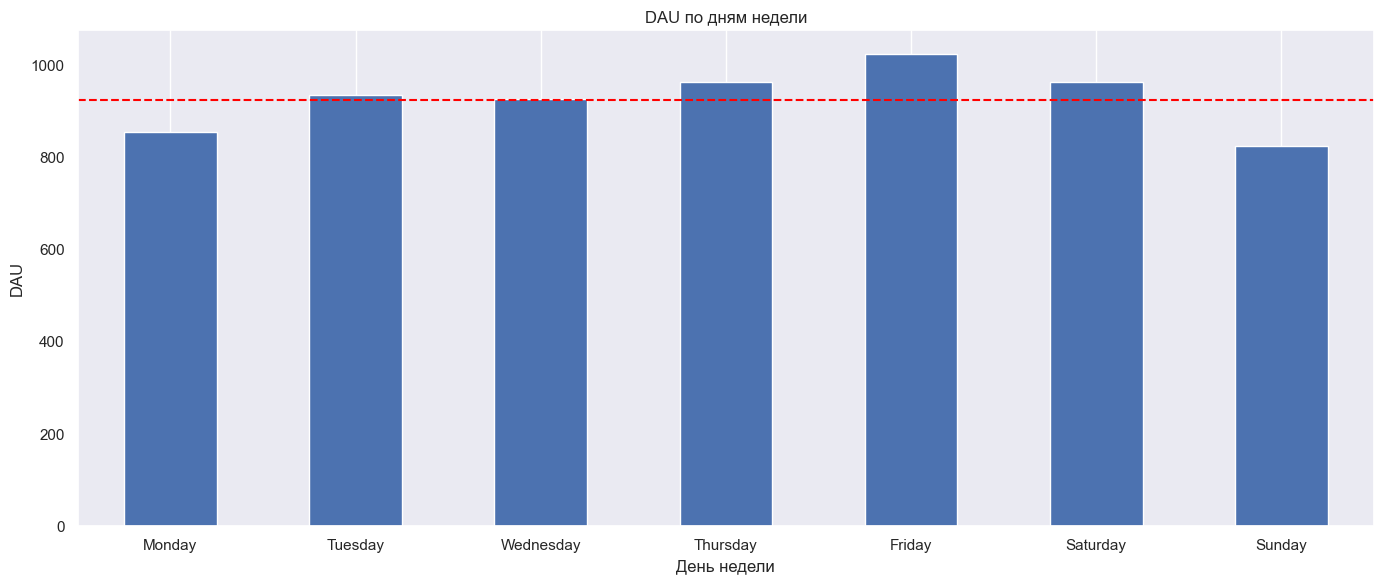

In [53]:
# Визуализируем информацию на графике
plt.figure(figsize=(14, 6))

week_dau.plot(kind='bar')

plt.title('DAU по дням недели')
plt.xlabel('День недели')
plt.ylabel('DAU')
plt.grid(axis='y')

plt.axhline(
    y=mean_line,
    color='red',
    linestyle='--'
)

plt.xticks(rotation=0)

plt.tight_layout()
plt.show()

In [54]:
# Посчитаем среднюю суммарную выручку за каждый день недели
week_revenue = (
    df[df['month'].isin([9,10])]
    .groupby([
        df['created_dt_msk'].dt.day_name(),
        df['created_dt_msk'].dt.date
    ])['revenue_rub'].sum().groupby(level=0).mean()
)
mean_line_rev = (
    df[df['month'].isin([9,10])]
    .groupby(
        df['created_dt_msk'].dt.date
    )['revenue_rub'].sum().mean()
)

week_revenue = week_revenue.reindex(days)
week_revenue

created_dt_msk
Monday       1.239093e+06
Tuesday      1.410882e+06
Wednesday    1.333046e+06
Thursday     1.493198e+06
Friday       1.638178e+06
Saturday     1.462576e+06
Sunday       1.207885e+06
Name: revenue_rub, dtype: float64

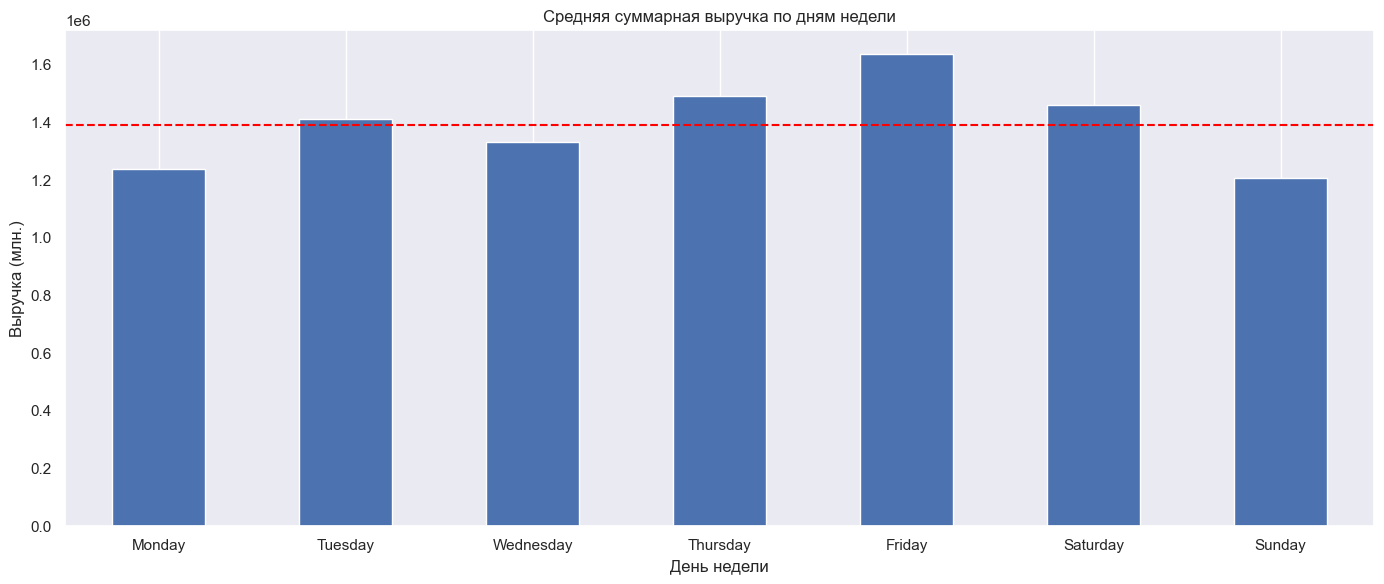

In [55]:
# Визуализируем информацию на графике
plt.figure(figsize=(14, 6))

week_revenue.plot(kind='bar')

plt.title('Средняя суммарная выручка по дням недели')
plt.xlabel('День недели')
plt.ylabel('Выручка (млн.)')
plt.grid(axis='y')

plt.axhline(
    y=mean_line_rev,
    color='red',
    linestyle='--'
)

plt.xticks(rotation=0)

plt.tight_layout()
plt.show()

#### Выводы

При анализе осенней активности пользователей можно отметить, что:
- В большинстве показателей происходят сильные колебания: в начале, конце сентября и в конце октября одновременно резко растет общее количество заказов и среднее количество билетов на пользователя, а средняя цена за билет падает до отметки ниже **1500** рублей. Скорее всего это совпадение неслучайно и обусловлено акционными предложениями. На данном отрезке, судя по возврату показателей к средним значениям, трудно сказать, повысили ли они интерес пользователей в долгосрочной перспективе. Только стабильно растущая ежедневная пользовательская активность косвенно может говорить о положительном влиянии проведенных акций.
- Средняя ежедневная пользовательская активность достигает пика в пятницу (**1025**) затем идет на спад в субботу (**962**) и достигает недельного минимума в воскресенье (**824**). С понедельника рост активности возобновляется. Это может быть обусловлено тем фактом, что последний рабочий день недели стимулирует желание пользователей "отпраздновать" его походом на какое-либо мероприятие.
- Суммарная выручка в целом коррелирует с числом активных пользователей - Чем больше DAU, тем больше выручка. Только лишь в среду едва заметна небольшая разница между выручкой и количеством активных пользователей.

### Популярные события и партнеры

После изучения динамики популярности событий и пользовательской активности осенью 2024 года, рассмотрим, как события распределены по регионам и партнерам. Это позволит выделить ключевые регионы и партнеров, которые вносят наибольший вклад в выручку.

#### Анализ мероприятий по регионам

In [56]:
# Создаем сводную таблицу мероприятий по регионам
pivot_region = pd.pivot_table(
    df,
    index=df['region_name'],
    values=['event_id','order_id'],
    aggfunc={'event_id':'nunique',
          'order_id':'count'}
).rename(columns={'event_id':'event_cnt_unique',
                 'order_id':'order_cnt'})
pivot_region['event_cnt_share'] = (
    pivot_region['event_cnt_unique'] / pivot_region['event_cnt_unique'].sum()
).round(3)
pivot_region['order_cnt_share'] = (
    pivot_region['order_cnt'] / pivot_region['order_cnt'].sum()
).round(3)
pivot_region.sort_values(by='event_cnt_unique',ascending=False).head(7)

,event_cnt_unique,order_cnt,event_cnt_share,order_cnt_share
region_name,,,,
Каменевский регион,5963,90632,0.267,0.316
Североярская область,3804,43834,0.170,0.153
Широковская область,1226,16371,0.055,0.057
Светополянский округ,1068,7558,0.048,0.026
Речиновская область,701,6289,0.031,0.022
Травяная область,683,5042,0.031,0.018
Горицветская область,551,5161,0.025,0.018


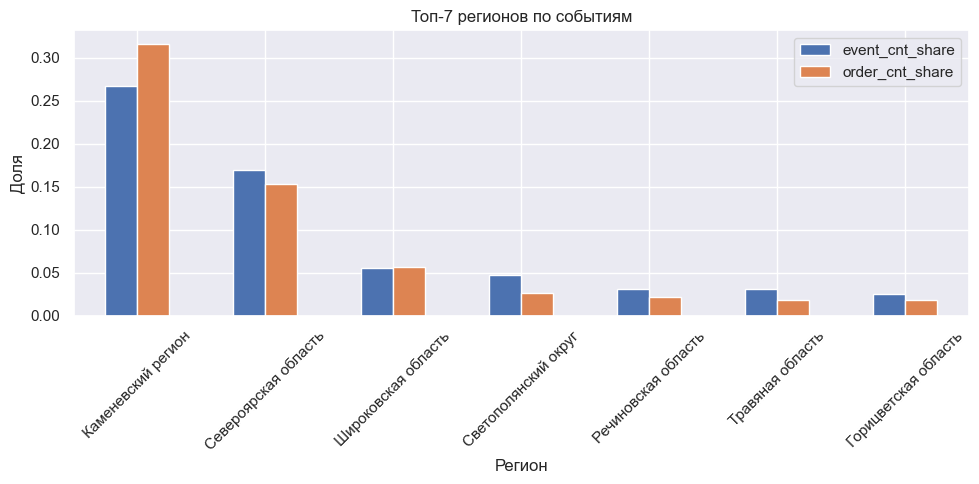

In [57]:
# Визуализируем сводную таблицу по регионам
pivot_region.sort_values(by='event_cnt_unique', ascending=False).head(7)[
    ['event_cnt_share', 'order_cnt_share']
].plot(kind='bar', figsize=(10,5))

plt.title('Топ-7 регионов по событиям')
plt.xlabel('Регион')
plt.ylabel('Доля')
plt.xticks(rotation=45)
plt.tight_layout()
plt.show()

#### Анализ мероприятий по билетным операторам

In [58]:
# Создаем сводную таблицу для каждого билетного партнера
pivot_service = pd.pivot_table(
    df,
    index=df['service_name'],
    values=['event_id','revenue_rub'],
    aggfunc={'event_id':'nunique',
          'revenue_rub':'sum'}
).rename(columns={'event_id':'event_cnt_unique',
                 'revenue_rub':'total_revenue'})
pivot_service['event_cnt_share'] = (
    pivot_service['event_cnt_unique']/pivot_service['event_cnt_unique'].sum()
).round(3)
pivot_service['revenue_share'] = (
    pivot_service['total_revenue'] / pivot_service['total_revenue'].sum()
).round(3)
pivot_service.sort_values(by='revenue_share',ascending=False).head(7)

,event_cnt_unique,total_revenue,event_cnt_share,revenue_share
service_name,,,,
Билеты без проблем,4209,2.538956e+07,0.173,0.167
Мой билет,1302,1.924235e+07,0.053,0.127
Облачко,2343,1.904531e+07,0.096,0.126
Лови билет!,4870,1.757097e+07,0.200,0.116
Весь в билетах,864,1.744457e+07,0.035,0.115
Билеты в руки,3523,1.333839e+07,0.145,0.088
Край билетов,252,6.630373e+06,0.010,0.044


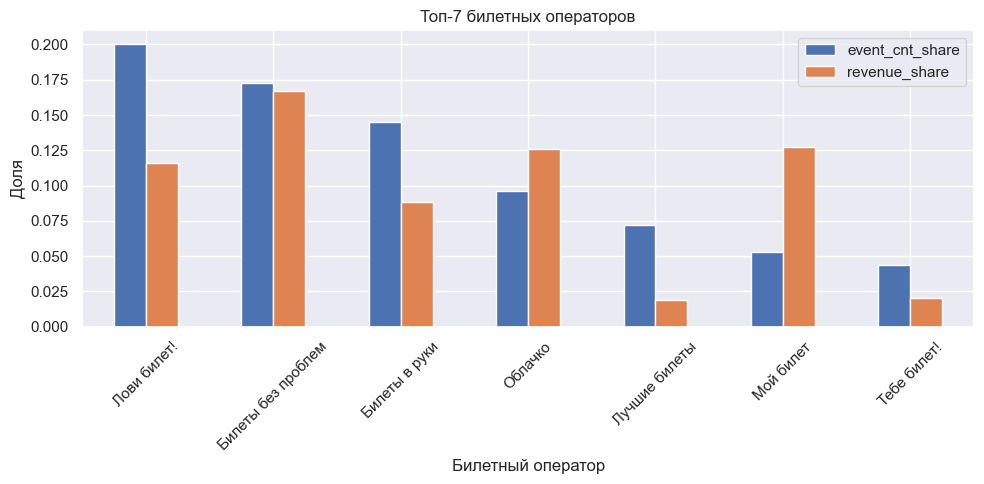

In [59]:
# Визуализируем сводную таблицу с топ билетных партнеров
pivot_service.sort_values(by='event_cnt_unique',ascending=False).head(7)[
    ['event_cnt_share', 'revenue_share']
].plot(kind='bar', figsize=(10,5))

plt.title('Топ-7 билетных операторов')
plt.xlabel('Билетный оператор')
plt.ylabel('Доля')
plt.xticks(rotation=45)
plt.tight_layout()
plt.show()

#### Выводы

По результатам проведенного исследования был определен топ популярных событий и партнеров по уникальному количеству мероприятий.

- Среди лидирующих регионов можно выделить *Каменевский район* (**5963 события, 26.7%**) и *Североярскую область* (**3804 события, 17%**). Судя по представленной визуализации видно, что эти два региона сильно выделяются среди остальных как по количеству уникальных мероприятий, так и по числу заказов. Вероятно, это связано с тем, что там сосредоточено больше пользователей, равно как и количество площадок, позволяющих провести больше мероприятий. 

- Из билетных партнеров  можно отметить "*Лови билет!*" (**4870 событий, 11.6%** общей выручки), "*Билеты без проблем*" (**4209 событий, 16.7%** всей выручки) и "*Билеты в руки*" (**3523 события, 8.8%** всей выручки). 

Стоит отметить, что количество заказов у билетных партнеров не коррелирует с долей выручки от продаж билетов. Разница между показателями может быть обусловлена разной финансовой политикой у билетных операторов. "*Лови билет!*", например, может продавать больше билетов, но брать меньше комиссии, тогда как "*Билеты без проблем*", не сильно уступая в продаже билетов, получает гораздо больше выручки с их продажи. Возможно, операторы, продающие больше билетов, пытаются набрать популярность за счет низких комиссий, тем самым получив большую доля рынка продажи билетов, а операторы с большей комиссией уже имеют высокую репутацию, поскольку пользователи продолжают пользоваться их услугами. Нельзя также забывать и о покупательной способности в разных регионах, которая непосредственно может влиять на предлагаемые операторами сервисы.

## Статистический анализ данных

Коллеги из продуктового отдела хотят отдельно проверить несколько гипотез относительно активности пользователей мобильных и стационарных устройств. Проверьте две гипотезы, которые предполагают большую активность пользователей мобильных устройств:

**Среднее количество заказов** на одного пользователя мобильного приложения выше по сравнению с пользователями стационарных устройств.

**Среднее время между заказами** пользователей мобильных приложений выше по сравнению с пользователями стационарных устройств.

Перед проведением гипотез необходимо изучить сравниваемые данные, обосновать выбор статистического теста, указать формулировку нулевой и альтернативной гипотез. Данные для гипотез нужны только за осенний период.

### Гипотеза о среднем количестве заказов

Сформируем нулевую и альтернативную гипотезы для среднего количества заказов на одного пользователя в зависимости от типа устройства.

*Нулевая гипотеза H0*: среднее количество заказов на одного пользователя мобильного приложения за осенний период **меньше или равно** среднему количеству заказов у пользователей стационарных устройств.

*Альтернативная гипотеза H1*: среднее количество заказов на одного пользователя мобильного приложения за осенний период **выше** по сравнению с пользователями стационарных устройств.
Прежде чем приступать к статистическому анализу, необходимо подготовить группы для анализа. 

Для проверки гипотез нам необходимо выявить пользователей, которые преимущественно используют мобильные или стационарные устройства, затем посчитать разницу и выявить предпочтительное устройство для каждого пользователя.

In [60]:
# Посчитаем для каждого пользователя количество заказов с мобильного и стационарного устройств
user_orders = df[df['month'].isin([9,10])].groupby(
    ['user_id', 'device_type_canonical']
)['order_id'].count().unstack()
user_orders.head()

device_type_canonical,desktop,mobile
user_id,,
0005ca5e93f2cf4,NaN,1.0
000898990054619,NaN,2.0
000a55a418c128c,NaN,2.0
001e7037d013f0f,NaN,2.0
00245c702bc343e,NaN,2.0


In [61]:
# Определяем разницу в ипользовании устройств для каждого пользователя
mobile_dekstop_diff = user_orders['mobile'] - user_orders['desktop']

In [62]:
# Рассмотрим описательную статистику распределения разностей
mobile_dekstop_diff.describe()

count    3258.000000
mean       22.153775
std       102.923910
min      -246.000000
25%         0.000000
50%         4.000000
75%        14.000000
max      2855.000000
dtype: float64

Несмотря на большую разницу между минимальным и максимальным значениями (пользователи делали очень много заказов либо с телефона, либо с компьютера), среднее и квантили находятся в пределах нормы.

Получается, что если у определенного пользователя результат разницы значений положительный, значит он сделал больше заказов сделал с мобильного устройства. Если результат отрицательный, то пользователь предпрочитает делать заказы со стационарного комппьютера. Если же разница равна нулю, то предпочтения пользователя равны. В нашем случае, ввиду большого объема данных, результат будет определять перекос в одну или другую сторону. 

Поскольку сравнение проводится внутри одного и того же пользователя, а распределение не содержит сильных выбросов и имеет достаточный объем наблюдений для проверки гипотезы, здесь подойдет ***парный t-тест Стьюдента*** (ttest_rel), который сводит задачу к анализу распределения попарных разностей и проверяет, отличается ли их среднее от нуля и если да, то в какую сторону.

In [63]:
# Проверяем гипотезу
alpha = 0.05

stat, p_value = ttest_rel(
    user_orders['mobile'],
    user_orders['desktop'],
    alternative='greater'
)

print('stat:', stat)
print('p_value:', p_value)
print()
if p_value > alpha:
    print('Нет оснований отвергнуть нулевую гипотезу.')
    print('Статистически значимых доказательств того, что среднее число заказов с мобильных устройств выше, чем с компьютеров, не обнаружено.')
else:
    print('Нулевая гипотеза отвергается в пользу альтернативной.')
    print('Среднее число заказов на одного пользователя с мобильных устройств статистически значимо выше, чем с компьютеров.')

stat: nan
p_value: nan

Нулевая гипотеза отвергается в пользу альтернативной.
Среднее число заказов на одного пользователя с мобильных устройств статистически значимо выше, чем с компьютеров.


#### Интепретация результатов

Значение **t-статистики** показывает, насколько средняя разность между мобильными и стационарными устройствами отклоняется от нуля в единицах стандартной ошибки, с учётом разброса данных и размера выборки. В данном случае значение положительное, а это означает, что пользователи в среднем делают больше заказов с мобильных устройств.

Очень низкое значение **p-value** в нашем случае означает крайне сильные статистические основания отвергнуть нулевую гипотезу и считать, что с мобильных устройств пользователи делают больше заказов, чем с компьютеров.

### Гипотеза о среднем времени между заказами

Сформируем нулевую и альтернативную гипотезы для среднего времени между заказами пользователей в зависимости от типа устройства.

*Нулевая гипотеза HO*: среднее время между заказами пользователей мобильных приложений за осенний период **меньше или равно** среднему времени между заказами пользователей стационарных устройств.

*Альтернативная гипотеза H1*: среднее время между заказами пользователей мобильных приложений за осенний период **выше** по сравнению с пользователями стационарных устройств.

Для проверки гипотез нам необходимо сначала определить и посчитать пользователей, которые преимущественно используют мобильные устройства или стационарные компьютеры, а затем, вычислив среднее время между заказами для каждого пользователя, связать его с предпочитаемым устройством.

In [64]:
# Оставляем только осенний период
df_prev = df[df['month'].isin([9, 10])].copy()

# Удаляем первые заказы пользователей с пропусками
df_prev = df_prev[df_prev['days_since_prev'].notna()].copy()

# Меняем формат столбца с типом устройства
df_prev['device_type_canonical'] = (
    df_prev['device_type_canonical']
    .astype(str)
)

# Считаем для каждого пользователя количество заказов с мобильного и стационарного устройств
user_orders_prev = (
    df_prev
    .groupby(
        ['user_id', 'device_type_canonical']
    )['order_id']
    .count()
    .unstack(fill_value=0)
)

In [65]:
# Определяем функцию для подсчета независимых групп
def define_user_group(row):

    mobile_orders = row.get('mobile', 0)
    desktop_orders = row.get('desktop', 0)

    # Предпочтительны мобильные устройства
    if mobile_orders > desktop_orders:
        return 'mobile'

    # Предпочтительны стационарные компьютеры
    if desktop_orders > mobile_orders:
        return 'desktop'
    
    # Смешанная группа
    else:
        return 'mixed'

# Создаем новый столбец и применяем к нему созданную функцию
user_orders_prev['group'] = user_orders_prev.apply(
    define_user_group,
    axis=1
)

# Проверяем результат
print(user_orders_prev['group'].value_counts())
print()
print(user_orders_prev.head(10))

group
mobile     9356
desktop    1427
mixed       376
Name: count, dtype: int64

device_type_canonical  desktop  mobile    group
user_id                                        
0005ca5e93f2cf4              0       1   mobile
000898990054619              0       2   mobile
000a55a418c128c              0       1   mobile
001e7037d013f0f              0       2   mobile
00245c702bc343e              0       2   mobile
0028d17a676f8c8              0       1   mobile
002b75ca606ba46              3       1  desktop
002ec276eee9b0b              1      11   mobile
0033403583a55ed              0       1   mobile
00345f897f95a34              0       4   mobile


In [66]:
# Высчитываем среднее время между заказами для каждого пользователя
user_mean_prev = (
    df_prev.groupby('user_id')['days_since_prev']
    .mean().reset_index()
)

# Добавляем группы пользователей
user_mean_prev = user_mean_prev.merge(
    user_orders_prev['group'],
    on='user_id'
)

# Проверяем результат
print(user_mean_prev.head(10))

           user_id  days_since_prev    group
0  0005ca5e93f2cf4            74.00   mobile
1  000898990054619            50.50   mobile
2  000a55a418c128c            15.00   mobile
3  001e7037d013f0f            43.50   mobile
4  00245c702bc343e            27.00   mobile
5  0028d17a676f8c8            28.00   mobile
6  002b75ca606ba46            19.25  desktop
7  002ec276eee9b0b             5.00   mobile
8  0033403583a55ed            20.00   mobile
9  00345f897f95a34            13.25   mobile


После определения пользовательских предпочтений можно перейти к формированию выборок и проверке гипотезы. В рамках исследования были выделены три группы пользователей: преимущественно использующие мобильные устройства, преимущественно использующие стационарные компьютеры и пользователи с одинаковыми предпочтениями по обоим устройствам. Поскольку третья группа является немногочисленной и не относится напрямую к рассматриваемой гипотезе, в дальнейшем анализе будут сравниваться только пользователи мобильных и стационарных устройств.

Несмотря на то что отдельные пользователи могли совершать заказы с разных устройств, каждый из них был отнесен только к одной группе на основе преобладающего типа устройства. Таким образом, сформированные выборки можно будет считать независимыми.

In [67]:
# Формируем выборки
mobile_users = user_mean_prev[
    user_mean_prev['group'] == 'mobile'
]['days_since_prev']

desktop_users = user_mean_prev[
    user_mean_prev['group'] == 'desktop'
]['days_since_prev']

# Посмотрим на описательную статистику обеих групп
print(mobile_users.describe())
print()
print(desktop_users.describe())

count    9356.000000
mean       20.334463
std        27.480778
min         0.000000
25%         1.875000
50%         9.222222
75%        27.000000
max       148.000000
Name: days_since_prev, dtype: float64

count    1427.000000
mean       23.442945
std        30.761332
min         0.000000
25%         1.000000
50%        10.666667
75%        33.416667
max       146.000000
Name: days_since_prev, dtype: float64


Показатели обеих выборок являются сравнительно близкими: отсутствуют явные признаки сильных выбросов, разница между средним и медианой невелика, а стандартное отклонение находится на умеренном уровне. Кроме того, объем выборок является достаточно большим, что позволяет применять параметрические методы проверки гипотез.

Таким образом, для проверки гипотезы может быть использован **односторонний t-критерий Стьюдента** для независимых выборок. Дополнительно целесообразно провести **тест Манна–Уитни** — непараметрический аналог t-критерия, более устойчивый к выбросам и отклонениям распределения от нормального.

In [68]:
# Проверяем гипотезу с помощью t-теста Стьюдента
stat, p_value = ttest_ind(
    mobile_users,
    desktop_users,
    alternative='greater'
)

print('stat:', stat)
print('p-value:', p_value)

if p_value < alpha:
    print('Отвергаем нулевую гипотезу в пользу альтернативной.')
    print('Среднее время между заказами у пользователей \nмобильных устройств статистически выше.')

else:
    print('Нет оснований отвергать нулевую гипотезу.')
    print('Недостаточно оснований считать, что среднее время \nмежду заказами у пользователей мобильных устройств выше.')

stat: -3.915243179771847
p-value: 0.999954565354446
Нет оснований отвергать нулевую гипотезу.
Недостаточно оснований считать, что среднее время 
между заказами у пользователей мобильных устройств выше.


In [69]:
# Проверяем гипотезу с помощью теста Манна–Уитни
stat, p_value = mannwhitneyu(
    mobile_users,
    desktop_users,
    alternative='greater'
)

print('U-statistic:', stat)
print('p-value:', p_value)

if p_value < alpha:
    print('Отвергаем нулевую гипотезу в пользу альтернативной.')
    print('Среднее время между заказами у пользователей мобильных устройств \nстатистически выше.')

else:
    print('Нет оснований отвергать нулевую гипотезу.')
    print('Недостаточно оснований считать, что среднее время \nмежду заказами у пользователей мобильных устройств выше.')

U-statistic: 6561423.0
p-value: 0.8517104354467596
Нет оснований отвергать нулевую гипотезу.
Недостаточно оснований считать, что среднее время 
между заказами у пользователей мобильных устройств выше.


#### Интерпретация результатов

Результаты одностороннего t-критерия Стьюдента показали, что оснований отвергать нулевую гипотезу нет. Полученное значение **p-value** значительно превышает уровень значимости, а отрицательное значение **t-статистики** указывает на то, что среднее время между заказами у пользователей мобильных устройств оказалось ниже, чем у пользователей стационарных устройств. Таким образом, гипотеза о более высоком среднем времени между заказами у мобильных пользователей не подтвердилась.

Результаты теста Манна–Уитни также не позволяют отвергнуть нулевую гипотезу. Значение **p-value** превышает уровень значимости, что свидетельствует об отсутствии статистически значимых различий между группами. Следовательно, полученные результаты не подтверждают гипотезу о том, что пользователи мобильных устройств совершают заказы с большим интервалом времени по сравнению с пользователями стационарных устройств.

## Общий вывод и рекомендации

После проведения комплексного исследования данных платформы Яндекс Афиша, включающего знакомство с датасетами `final_tickets_orders_df` с информацией о заказах билетов и `final_tickets_events_df` с информацией о событиях, их предобработку, объединение и анализ динамики ключевых показателей в летний и осенний периоды 2024 года, можно сформулировать общие выводы и рекомендации.

### Общие выводы

- Проведенный анализ показал, что пользовательская активность на платформе имеет выраженную сезонность. В осенний период количество заказов заметно увеличивается, особенно среди мобильных пользователей, а наиболее востребованными категориями мероприятий являются театральные и спортивные события. Это позволяет предположить, что после летнего периода пользователи возвращаются к более активному планированию досуга, а сама платформа становится особенно востребованной в период начала учебного года и возвращения к рабочему ритму.

- Рост количества заказов в ряде категорий сопровождался снижением средней стоимости билетов. Вероятно, увеличение спроса поддерживалось маркетинговыми активностями, скидками и акционными предложениями. Таким образом, рост продаж был достигнут не только за счет повышения интереса пользователей к мероприятиям, но и за счет ценовых стимулов.

- Анализ пользовательской активности также выявил выраженную недельную сезонность: наибольшее количество заказов приходится на пятницу. Это указывает на то, что пользователи чаще принимают решение о покупке билетов непосредственно перед выходными и заранее планируют свободное время.

- Дополнительно анализ показал наличие регионов и партнеров-лидеров по числу заказов и объему выручки, что свидетельствует о неравномерном распределении спроса между различными сегментами и может быть использовано для более точечного развития бизнеса и маркетинговых кампаний.

- Проверка статистических гипотез не выявила значимых различий во времени между заказами пользователей мобильных и стационарных устройств. Это означает, что различия между типами устройств проявляются скорее в объеме использования и удобстве взаимодействия, чем в частоте пользовательской активности.

- В совокупности результаты исследования показывают, что основными драйверами для роста платформы являются сезонный спрос, удобство мобильного приложения и эффективные маркетинговые активности.

### Рекомендации бизнесу

- Усилить маркетинговую активность в конце августа и начале сентября, поскольку именно в этот период наблюдается рост пользовательского спроса и количества заказов.

- Продолжить развитие мобильного приложения и мобильной версии платформы, уделяя особое внимание удобству оформления заказов и улучшению пользовательского опыта.

- Использовать пятницу и предвыходные дни для запуска рекламных кампаний, push-уведомлений и email-рассылок, так как именно в этот период наблюдается пик пользовательской активности.

- Анализировать эффективность скидок и акционных предложений, чтобы оценивать их влияние не только на рост заказов, но и на итоговую выручку.

- Развивать персонализированные рекомендации мероприятий на основе пользовательского интереса и истории заказов.

- Уделить дополнительное внимание регионам и партнерам-лидерам, а также изучить причины различий между сегментами для более эффективного распределения маркетинговых ресурсов.

- Продолжить анализ данных на более длительном временном промежутке для более точного изучения сезонности и изменения поведения пользователей.